# From NHANES Survey Data to Vivarium Risk Exposure

This notebook walks through the full pipeline:

1. **Download** liver stiffness measurement (LSM) data from NHANES 2017+
2. **Analyze** the exposure distribution by GBD standard 5-year age groups and sex
3. **Build** a vivarium data artifact containing the risk exposure
4. **Run** a vivarium microsimulation that assigns liver stiffness to simulants

Liver stiffness (measured in kilopascals via FibroScan) is a biomarker for
liver fibrosis. Higher values indicate more fibrosis. We treat it as a
continuous risk factor with a lognormal distribution (since LSM values are
right-skewed and strictly positive).

## 1. Setup and Data Download

In [1]:
import os, hashlib, warnings
import requests
import numpy as np
import pandas as pd
import pyreadstat
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore', category=FutureWarning)

DATA_DIR   = os.path.abspath(os.path.join('..', 'data'))
RAW_NHANES = os.path.join(DATA_DIR, 'raw', 'nhanes')
DERIVED    = os.path.join(DATA_DIR, 'derived')
OUTPUT_DIR = os.path.join('.', 'outputs')
os.makedirs(DERIVED, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

NHANES_BASE = 'https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public'

print(f'Data directory: {DATA_DIR}')
print(f'Output directory: {os.path.abspath(OUTPUT_DIR)}')

Data directory: /home/abie/ai_assisted_us_health_data_analysis/data
Output directory: /home/abie/ai_assisted_us_health_data_analysis/nhanes_vivarium_risk_demo/outputs


In [2]:
def download(url, dest):
    """Download with caching."""
    if os.path.exists(dest):
        print(f'  cached: {os.path.basename(dest)}')
        return dest
    print(f'  GET {url}')
    r = requests.get(url, timeout=180)
    r.raise_for_status()
    with open(dest, 'wb') as f:
        f.write(r.content)
    md5 = hashlib.md5(r.content).hexdigest()
    print(f'    -> {os.path.basename(dest)} ({len(r.content):,} bytes, md5={md5})')
    return dest


def read_xpt(path):
    try:
        df, _ = pyreadstat.read_xport(path)
    except UnicodeDecodeError:
        df, _ = pyreadstat.read_xport(path, encoding='latin1')
    return df

### NHANES cycles with liver stiffness

FibroScan (VCTE) was added in 2017. Two non-overlapping analysis cycles:

| Cycle | Prefix/Suffix | Notes |
|-------|--------------|-------|
| 2017-March 2020 Pre-Pandemic | `P_` prefix | Supersedes 2017-2018 standalone |
| 2021-2022 | `_L` suffix | Post-pandemic restart |

In [3]:
CYCLES = [
    {
        'label': '2017-2020',
        'dirname': '2017_2020_prepandemic',
        'year': 2017,
        'prefix': 'P_',
        'suffix': '',
        'files': ['DEMO', 'LUX'],  # Only need demographics + liver ultrasound
    },
    {
        'label': '2021-2022',
        'dirname': '2021_2022',
        'year': 2021,
        'prefix': '',
        'suffix': '_L',
        'files': ['DEMO', 'LUX'],
    },
]


def fname(cycle, component):
    return f"{cycle['prefix']}{component}{cycle['suffix']}.xpt"


def furl(cycle, component):
    return f"{NHANES_BASE}/{cycle['year']}/DataFiles/{fname(cycle, component)}"

In [4]:
raw = {}
for cyc in CYCLES:
    print(f"\n=== {cyc['label']} ===")
    cdir = os.path.join(RAW_NHANES, cyc['dirname'])
    os.makedirs(cdir, exist_ok=True)
    raw[cyc['label']] = {}
    for name in cyc['files']:
        path = download(furl(cyc, name), os.path.join(cdir, fname(cyc, name)))
        raw[cyc['label']][name] = read_xpt(path)
        print(f'    {name}: {len(raw[cyc["label"]][name]):,} rows')

print('\nAll downloads complete.')


=== 2017-2020 ===
  cached: P_DEMO.xpt
    DEMO: 15,560 rows
  cached: P_LUX.xpt
    LUX: 10,409 rows

=== 2021-2022 ===
  cached: DEMO_L.xpt
    DEMO: 11,933 rows
  cached: LUX_L.xpt
    LUX: 7,199 rows

All downloads complete.


### Merge demographics + liver stiffness

In [5]:
dfs = []
for cyc in CYCLES:
    label = cyc['label']
    demo = raw[label]['DEMO'].copy()
    lux = raw[label]['LUX'][['SEQN', 'LUXSMED']].rename(columns={'LUXSMED': 'LSM_KPA'})

    df = demo.merge(lux, on='SEQN', how='left')

    # Filter to exam-eligible adults >= 18
    df = df[df['RIDSTATR'] == 2].copy()
    df['AGE'] = df['RIDAGEYR']
    df = df[df['AGE'] >= 18].copy()
    df['SEX'] = df['RIAGENDR'].map({1: 'Male', 2: 'Female'})
    df['CYCLE'] = label

    # Survey weight for the elastography subsample
    # WTMECPRP / WTMEC2YR is the MEC exam weight
    wt_col = 'WTMECPRP' if 'WTMECPRP' in df.columns else 'WTMEC2YR'
    df['WEIGHT'] = df[wt_col]

    dfs.append(df[['SEQN', 'AGE', 'SEX', 'LSM_KPA', 'WEIGHT', 'CYCLE']])
    n_lsm = df['LSM_KPA'].notna().sum()
    print(f"{label}: {len(df):,} adults, {n_lsm:,} with LSM ({n_lsm/len(df)*100:.0f}%)")

nhanes = pd.concat(dfs, ignore_index=True)
nhanes_lsm = nhanes.dropna(subset=['LSM_KPA', 'WEIGHT']).copy()
print(f"\nPooled analytic sample: {len(nhanes_lsm):,} adults with valid LSM and weights")

2017-2020: 8,965 adults, 8,318 with LSM (93%)
2021-2022: 6,337 adults, 5,874 with LSM (93%)

Pooled analytic sample: 14,192 adults with valid LSM and weights


## 2. Analyze Liver Stiffness by GBD Age Groups

GBD uses standard 5-year age bins. We compute weighted mean and SD of
log(LSM) within each age/sex stratum. We use log-transformed values because
LSM is right-skewed and strictly positive, so a lognormal distribution
is a natural fit.

In [6]:
# GBD standard 5-year age groups (adult range relevant to NHANES LSM)
GBD_AGE_BINS = [
    (15, 20), (20, 25), (25, 30), (30, 35), (35, 40),
    (40, 45), (45, 50), (50, 55), (55, 60), (60, 65),
    (65, 70), (70, 75), (75, 80), (80, 85), (85, 90),
    (90, 95), (95, 125),
]

nhanes_lsm['age_group'] = pd.cut(
    nhanes_lsm['AGE'],
    bins=[b[0] for b in GBD_AGE_BINS] + [GBD_AGE_BINS[-1][1]],
    right=False,
    labels=[f'{a}-{b}' for a, b in GBD_AGE_BINS],
)

# Log-transform for lognormal fitting
nhanes_lsm['log_LSM'] = np.log(nhanes_lsm['LSM_KPA'])

print(f'Age group distribution:')
print(nhanes_lsm.groupby('age_group', observed=True).size().to_string())

Age group distribution:
age_group
15-20     654
20-25     874
25-30     917
30-35    1072
35-40     988
40-45    1054
45-50     973
50-55    1040
55-60    1221
60-65    1640
65-70    1313
70-75    1062
75-80     643
80-85     741


In [7]:
def weighted_mean(values, weights):
    return np.average(values, weights=weights)


def weighted_std(values, weights):
    avg = weighted_mean(values, weights)
    variance = np.average((values - avg) ** 2, weights=weights)
    return np.sqrt(variance)


# Compute weighted mean and SD of LSM by age group and sex
rows = []
for (age_grp, sex), g in nhanes_lsm.groupby(['age_group', 'SEX'], observed=True):
    age_start = int(age_grp.split('-')[0])
    age_end = int(age_grp.split('-')[1])
    rows.append({
        'age_start': float(age_start),
        'age_end': float(age_end),
        'sex': sex,
        'n': len(g),
        'mean_lsm': weighted_mean(g['LSM_KPA'].values, g['WEIGHT'].values),
        'sd_lsm': weighted_std(g['LSM_KPA'].values, g['WEIGHT'].values),
        'median_lsm': g['LSM_KPA'].median(),
    })

exposure_summary = pd.DataFrame(rows)
print('Weighted liver stiffness (kPa) by GBD age group and sex:')
display(exposure_summary.style.format({
    'mean_lsm': '{:.2f}', 'sd_lsm': '{:.2f}', 'median_lsm': '{:.1f}',
    'age_start': '{:.0f}', 'age_end': '{:.0f}',
}))

Weighted liver stiffness (kPa) by GBD age group and sex:


,age_start,age_end,sex,n,mean_lsm,sd_lsm,median_lsm
0,15,20,Female,302,4.81,3.56,4.5
1,15,20,Male,352,5.40,2.38,4.8
2,20,25,Female,429,4.65,1.77,4.5
3,20,25,Male,445,5.91,4.35,5.1
4,25,30,Female,482,4.95,2.33,4.5
5,25,30,Male,435,5.59,4.69,5.1
6,30,35,Female,550,5.34,6.01,4.4
7,30,35,Male,522,5.86,4.15,5.2
8,35,40,Female,556,5.33,4.08,4.6
9,35,40,Male,432,6.03,5.86,5.1


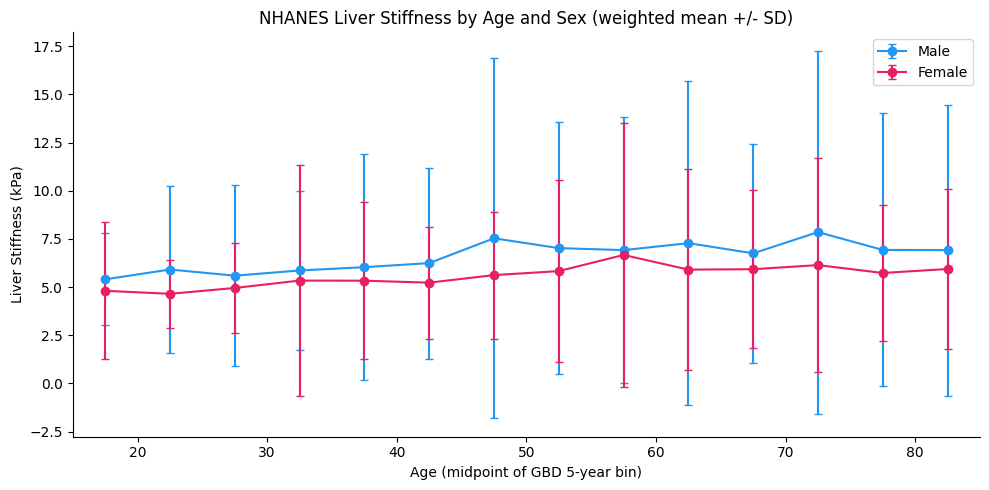

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))

for sex, color in [('Male', '#2196F3'), ('Female', '#E91E63')]:
    sub = exposure_summary[exposure_summary['sex'] == sex].copy()
    age_mid = (sub['age_start'] + sub['age_end']) / 2
    ax.errorbar(
        age_mid, sub['mean_lsm'], yerr=sub['sd_lsm'],
        label=sex, color=color, capsize=3, marker='o', linewidth=1.5,
    )

ax.set_xlabel('Age (midpoint of GBD 5-year bin)')
ax.set_ylabel('Liver Stiffness (kPa)')
ax.set_title('NHANES Liver Stiffness by Age and Sex (weighted mean +/- SD)')
ax.legend()
ax.set_xlim(15, 85)
sns.despine()
plt.tight_layout()
plt.show()

## 3. Build the Vivarium Data Artifact

A vivarium artifact is an HDF5 file containing all data a simulation needs.
For a minimal simulation with one continuous risk factor, we need:

| Artifact Key | Content |
|---|---|
| `population.structure` | Population counts by age/sex/year (for demographic sampling) |
| `population.location` | Location name string |
| `population.theoretical_minimum_risk_life_expectancy` | TMRLE table (for mortality) |
| `cause.all_causes.cause_specific_mortality_rate` | All-cause mortality rate |
| `risk_factor.liver_stiffness.distribution` | Distribution type ("lognormal") |
| `risk_factor.liver_stiffness.exposure` | Mean exposure by age/sex/year |
| `risk_factor.liver_stiffness.exposure_standard_deviation` | SD by age/sex/year |

**Important implementation details:**

- DataFrames must be indexed by `(sex, age_start, age_end, year_start, year_end)` before
  writing to the artifact. The vivarium `ArtifactManager` calls `reset_index()` on load;
  a default integer index would produce a spurious `index` column that breaks lookup tables.
- Data must span enough year bins to cover the simulation's start year. We replicate the
  same values across 2020-2030 to be safe.

### 3a. Population structure

We create a simple flat population structure (equal counts in each bin).
In a real project, you would pull this from GBD or census data.

In [9]:
YEAR_START = 2024
YEAR_END = 2025
INDEX_COLS = ['sex', 'age_start', 'age_end', 'year_start', 'year_end']

pop_rows = []
for age_start, age_end in GBD_AGE_BINS:
    for sex in ['Female', 'Male']:
        pop_rows.append({
            'age_start': float(age_start),
            'age_end': float(age_end),
            'sex': sex,
            'year_start': YEAR_START,
            'year_end': YEAR_END,
            'value': 1000.0,  # Flat population; equal weight per bin
        })

pop_structure = pd.DataFrame(pop_rows)
print(f'Population structure: {len(pop_structure)} rows (age/sex bins)')
display(pop_structure.head(6))

Population structure: 34 rows (age/sex bins)


,age_start,age_end,sex,year_start,year_end,value
0,15.0,20.0,Female,2024,2025,1000.0
1,15.0,20.0,Male,2024,2025,1000.0
2,20.0,25.0,Female,2024,2025,1000.0
3,20.0,25.0,Male,2024,2025,1000.0
4,25.0,30.0,Female,2024,2025,1000.0
5,25.0,30.0,Male,2024,2025,1000.0


### 3b. Risk exposure data

Convert the NHANES summary statistics into the vivarium artifact format.
Each row is an age/sex/year bin with a `value` column.

For age groups with no NHANES data (e.g. 85+, which has few or no observations),
we carry forward the last observed value.

In [10]:
def build_artifact_table(exposure_summary, value_col, year_start, year_end):
    """Convert exposure_summary into vivarium artifact format.

    Fills missing age groups (those with no NHANES data) by carrying
    forward the nearest observed value within each sex.
    """
    rows = []
    for sex in ['Female', 'Male']:
        sub = exposure_summary[exposure_summary['sex'] == sex].sort_values('age_start')
        # Build a lookup from observed data
        observed = dict(zip(sub['age_start'], sub[value_col]))

        last_val = None
        for age_start, age_end in GBD_AGE_BINS:
            val = observed.get(float(age_start), None)
            if val is not None:
                last_val = val
            elif last_val is not None:
                val = last_val  # carry forward
            else:
                # Before any observations (shouldn't happen for adults)
                val = sub[value_col].iloc[0] if len(sub) > 0 else 0.0

            rows.append({
                'sex': sex,
                'age_start': float(age_start),
                'age_end': float(age_end),
                'year_start': year_start,
                'year_end': year_end,
                'value': float(val),
            })

    return pd.DataFrame(rows)


exposure_table = build_artifact_table(exposure_summary, 'mean_lsm', YEAR_START, YEAR_END)
exposure_sd_table = build_artifact_table(exposure_summary, 'sd_lsm', YEAR_START, YEAR_END)

print('Exposure table (mean LSM in kPa):')
display(exposure_table.head(6))
print(f'\nTotal rows: {len(exposure_table)}')

Exposure table (mean LSM in kPa):


,sex,age_start,age_end,year_start,year_end,value
0,Female,15.0,20.0,2024,2025,4.806075
1,Female,20.0,25.0,2024,2025,4.650091
2,Female,25.0,30.0,2024,2025,4.953764
3,Female,30.0,35.0,2024,2025,5.336628
4,Female,35.0,40.0,2024,2025,5.329860
5,Female,40.0,45.0,2024,2025,5.229630



Total rows: 34


### 3c. Mortality data (placeholder)

BasePopulation requires mortality data. We use near-zero mortality so
the demo focuses on the risk exposure rather than demographic dynamics.

In [11]:
# Near-zero ACMR so nobody dies during the demo
acmr_rows = []
for age_start, age_end in GBD_AGE_BINS:
    for sex in ['Female', 'Male']:
        acmr_rows.append({
            'sex': sex,
            'age_start': float(age_start),
            'age_end': float(age_end),
            'year_start': YEAR_START,
            'year_end': YEAR_END,
            'value': 1e-9,
        })

acmr_table = pd.DataFrame(acmr_rows)

# TMRLE: theoretical minimum risk life expectancy
# Simple table — just needs age_start, age_end, value
tmrle_rows = []
for age_start, age_end in GBD_AGE_BINS:
    remaining = max(100 - age_start, 0.5)
    tmrle_rows.append({
        'sex': 'Female',
        'age_start': float(age_start),
        'age_end': float(age_end),
        'year_start': YEAR_START,
        'year_end': YEAR_END,
        'value': remaining,
    })
    tmrle_rows.append({
        'sex': 'Male',
        'age_start': float(age_start),
        'age_end': float(age_end),
        'year_start': YEAR_START,
        'year_end': YEAR_END,
        'value': remaining,
    })

tmrle_table = pd.DataFrame(tmrle_rows)
print(f'ACMR table: {len(acmr_table)} rows')
print(f'TMRLE table: {len(tmrle_table)} rows')

ACMR table: 34 rows
TMRLE table: 34 rows


### 3d. Write the artifact

In [12]:
from vivarium.framework.artifact import Artifact

ARTIFACT_PATH = os.path.join(OUTPUT_DIR, 'nhanes_liver_stiffness.hdf')

# Remove existing artifact to start fresh
if os.path.exists(ARTIFACT_PATH):
    os.remove(ARTIFACT_PATH)

# Replicate all tables across multiple year bins so the simulation
# can find data for any start year in the 2020-2030 range.
def expand_years(df, year_pairs):
    """Replicate a single-year table across multiple year bins."""
    pieces = []
    for ys, ye in year_pairs:
        chunk = df.copy()
        chunk['year_start'] = ys
        chunk['year_end'] = ye
        pieces.append(chunk)
    return pd.concat(pieces, ignore_index=True).set_index(INDEX_COLS)

YEAR_BINS = [(2020 + i, 2021 + i) for i in range(11)]  # 2020-2030

artifact = Artifact(ARTIFACT_PATH)

# Population data
artifact.write('population.location', 'United States')
artifact.write('population.structure', expand_years(pop_structure, YEAR_BINS))
artifact.write('population.theoretical_minimum_risk_life_expectancy',
               expand_years(tmrle_table, YEAR_BINS))

# Mortality
artifact.write('cause.all_causes.cause_specific_mortality_rate',
               expand_years(acmr_table, YEAR_BINS))

# Risk factor: liver stiffness
artifact.write('risk_factor.liver_stiffness.distribution', 'lognormal')
artifact.write('risk_factor.liver_stiffness.exposure',
               expand_years(exposure_table, YEAR_BINS))
artifact.write('risk_factor.liver_stiffness.exposure_standard_deviation',
               expand_years(exposure_sd_table, YEAR_BINS))

print('Artifact contents:')
print(artifact)

Artifact contents:
Artifact containing the following keys:
metadata
	keyspace
population
	location
	structure
	theoretical_minimum_risk_life_expectancy
cause
	all_causes
		cause_specific_mortality_rate
risk_factor
	liver_stiffness
		distribution
		exposure
		exposure_standard_deviation



/home/abie/miniforge3/envs/vivarium_csu_mace_rct/lib/python3.12/site-packages/vivarium/framework/artifact/artifact.py:69: UserWarning: No artifact found at outputs/nhanes_liver_stiffness.hdf. Building new artifact.
  warnings.warn(f"No artifact found at {path}. Building new artifact.")


## 4. Initialize and Run the Vivarium Simulation

We use `InteractiveContext` to build a simulation with:
- `BasePopulation` for demographic structure
- `Risk("risk_factor.liver_stiffness")` for the LSM exposure

**Note:** vivarium_public_health 5.0.0 has a bug where `ContinuousDistribution.setup`
is defined twice, so the exposure parameters pipeline never gets registered. We apply
a one-line fix below.

In [13]:
from vivarium import InteractiveContext
from vivarium_public_health.population import BasePopulation
from vivarium_public_health.risks import Risk
from vivarium_public_health.risks.distributions import ContinuousDistribution

# Fix vivarium_public_health 5.0.0 bug: ContinuousDistribution defines setup()
# twice. The second definition builds the parameters lookup table but never
# registers it as an attribute pipeline, causing a KeyError during post-setup
# resource resolution. We patch it to add the missing registration.
_original_continuous_setup = ContinuousDistribution.setup

def _fixed_continuous_setup(self, builder):
    _original_continuous_setup(self, builder)
    builder.value.register_attribute_producer(
        self.exposure_params_name, source=self.parameters_table
    )

ContinuousDistribution.setup = _fixed_continuous_setup

sim = InteractiveContext(
    components=[
        BasePopulation(),
        Risk('risk_factor.liver_stiffness'),
    ],
    configuration={
        'input_data': {
            'artifact_path': os.path.abspath(ARTIFACT_PATH),
        },
        'interpolation': {
            'order': 0,
            'extrapolate': True,
        },
        'randomness': {
            'map_size': 1_000_000,
            'key_columns': ['entrance_time', 'age'],
            'random_seed': 42,
        },
        'time': {
            'start': {'year': YEAR_START, 'month': 1, 'day': 1},
            'end': {'year': YEAR_START, 'month': 7, 'day': 1},
            'step_size': 28,
        },
        'population': {
            'population_size': 10_000,
            'initialization_age_min': 18,
            'initialization_age_max': 95,
        },
    },
)

pop = sim.get_population(['age', 'sex'])
print(f'Simulation initialized with {len(pop)} simulants')

2026-04-15 21:54:56.694 | INFO     | simulation_1-artifact_manager:80 - Running simulation from artifact located at /home/abie/ai_assisted_us_health_data_analysis/nhanes_vivarium_risk_demo/outputs/nhanes_liver_stiffness.hdf.


2026-04-15 21:54:56.695 | INFO     | simulation_1-artifact_manager:81 - Artifact base filter terms are [].


2026-04-15 21:54:56.696 | INFO     | simulation_1-artifact_manager:82 - Artifact additional filter terms are None.


2026-04-15 21:54:57.018 | WARNING  | simulation_1-lookup_table_manager:85 - Component 'risk_factor.liver_stiffness' configured, but didn't build lookup table 'exposure' during setup.


2026-04-15 21:54:57.019 | WARNING  | simulation_1-lookup_table_manager:85 - Component 'risk_factor.liver_stiffness' configured, but didn't build lookup table 'ensemble_distribution_weights' during setup.


2026-04-15 21:54:57.020 | WARNING  | simulation_1-lookup_table_manager:85 - Component 'risk_factor.liver_stiffness' configured, but didn't build lookup table 'exposure_standard_deviation' during setup.


Simulation initialized with 10000 simulants


### Validate: check that exposures are assigned

In [14]:
pop = sim.get_population(['age', 'sex', 'liver_stiffness.exposure'])
pop = pop.rename(columns={'liver_stiffness.exposure': 'liver_stiffness_kpa'})

print('Population with assigned liver stiffness (first 10):')
display(pop[['age', 'sex', 'liver_stiffness_kpa']].head(10))

print(f'\nLiver stiffness summary:')
print(f'  Min:    {pop["liver_stiffness_kpa"].min():.2f} kPa')
print(f'  Median: {pop["liver_stiffness_kpa"].median():.2f} kPa')
print(f'  Mean:   {pop["liver_stiffness_kpa"].mean():.2f} kPa')
print(f'  Max:    {pop["liver_stiffness_kpa"].max():.2f} kPa')
print(f'  Any NaN: {pop["liver_stiffness_kpa"].isna().any()}')

Population with assigned liver stiffness (first 10):


/home/abie/miniforge3/envs/vivarium_csu_mace_rct/lib/python3.12/site-packages/vivarium_public_health/risks/distributions.py:518: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q[q > Q_UPPER_BOUND] = Q_UPPER_BOUND
/home/abie/miniforge3/envs/vivarium_csu_mace_rct/lib/python3.12/site-packages/vivarium_public_health/risks/distributions.py:518: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q[q > Q_UPPER_BOUND] = Q_UPPER_BOUND
/home/abie/miniforge3/envs/vivarium_csu_mace_rct/lib/python3.12/site-packages/vivarium_public_health/risks/distributions.py:519: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

,age,sex,liver_stiffness_kpa
0,84.227129,Male,2.722361
1,30.082087,Male,5.729826
2,35.636718,Male,5.712381
3,75.514291,Female,4.023284
4,22.093072,Female,7.114104
5,45.582160,Male,15.688376
6,41.821930,Male,8.656293
7,18.383201,Female,6.221650
8,69.684707,Female,7.878900
9,78.596854,Female,7.945433



Liver stiffness summary:
  Min:    0.28 kPa
  Median: 4.58 kPa
  Mean:   6.07 kPa
  Max:    76.10 kPa
  Any NaN: False


In [15]:
# Compare simulation exposure means to the NHANES input data
pop['age_group'] = pd.cut(
    pop['age'],
    bins=[b[0] for b in GBD_AGE_BINS] + [GBD_AGE_BINS[-1][1]],
    right=False,
    labels=[f'{a}-{b}' for a, b in GBD_AGE_BINS],
)

sim_means = pop.groupby(['age_group', 'sex'], observed=True)['liver_stiffness_kpa'].mean()

comparison = exposure_summary[['age_start', 'age_end', 'sex', 'mean_lsm', 'n']].copy()
comparison['age_label'] = comparison.apply(
    lambda r: f"{int(r['age_start'])}-{int(r['age_end'])}", axis=1,
)
comparison['sim_mean'] = comparison.apply(
    lambda r: sim_means.get((r['age_label'], r['sex']), np.nan), axis=1,
)

print('Comparison: NHANES input mean vs. simulation mean (kPa):')
display(comparison[['age_label', 'sex', 'n', 'mean_lsm', 'sim_mean']].rename(
    columns={'mean_lsm': 'nhanes_mean', 'age_label': 'age_group'}
).style.format({'nhanes_mean': '{:.2f}', 'sim_mean': '{:.2f}'}))

Comparison: NHANES input mean vs. simulation mean (kPa):


,age_group,sex,n,nhanes_mean,sim_mean
0,15-20,Female,302,4.81,4.63
1,15-20,Male,352,5.40,4.98
2,20-25,Female,429,4.65,4.84
3,20-25,Male,445,5.91,5.61
4,25-30,Female,482,4.95,4.86
5,25-30,Male,435,5.59,5.40
6,30-35,Female,550,5.34,4.87
7,30-35,Male,522,5.86,5.86
8,35-40,Female,556,5.33,5.24
9,35-40,Male,432,6.03,5.74


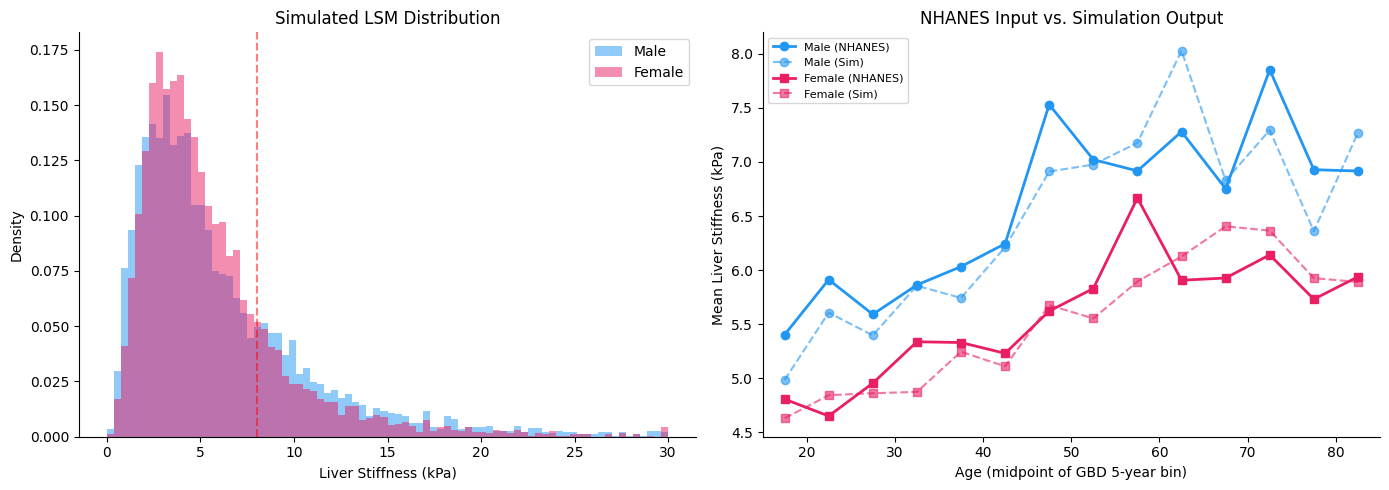

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: distribution of simulated exposures
ax = axes[0]
for sex, color in [('Male', '#2196F3'), ('Female', '#E91E63')]:
    sub = pop[pop['sex'] == sex]
    ax.hist(sub['liver_stiffness_kpa'], bins=80, alpha=0.5, color=color,
            label=sex, density=True, range=(0, 30))
ax.set_xlabel('Liver Stiffness (kPa)')
ax.set_ylabel('Density')
ax.set_title('Simulated LSM Distribution')
ax.legend()
ax.axvline(x=8.0, color='red', linestyle='--', alpha=0.5, label='F2+ threshold')
sns.despine(ax=ax)

# Right: NHANES vs simulation means by age
ax = axes[1]
for sex, color, marker in [('Male', '#2196F3', 'o'), ('Female', '#E91E63', 's')]:
    sub_nhanes = comparison[comparison['sex'] == sex]
    age_mid = (sub_nhanes['age_start'] + sub_nhanes['age_end']) / 2
    ax.plot(age_mid, sub_nhanes['mean_lsm'],
            marker=marker, color=color, label=f'{sex} (NHANES)', linewidth=2)
    ax.plot(age_mid, sub_nhanes['sim_mean'],
            marker=marker, color=color, linestyle='--', alpha=0.6,
            label=f'{sex} (Sim)')
ax.set_xlabel('Age (midpoint of GBD 5-year bin)')
ax.set_ylabel('Mean Liver Stiffness (kPa)')
ax.set_title('NHANES Input vs. Simulation Output')
ax.legend(fontsize=8)
ax.set_xlim(15, 85)
sns.despine(ax=ax)

plt.tight_layout()
plt.show()

### Step the simulation forward

In [17]:
print(f'Time before stepping: {sim.current_time}')
sim.step()  # Advance one time step (28 days)
print(f'Time after stepping:  {sim.current_time}')

pop_after = sim.get_population(['age', 'sex', 'liver_stiffness.exposure'])
print(f'\nAll simulants still have exposures: {pop_after["liver_stiffness.exposure"].notna().all()}')
print(f'Mean LSM after step: {pop_after["liver_stiffness.exposure"].mean():.2f} kPa')

Time before stepping: 2024-01-01 00:00:00
2026-04-15 21:54:57.603 | INFO     | simulation_1 - vivarium.framework.engine:280 - 2024-01-01 00:00:00


2026-04-15 21:54:57.618 | WARNING  | simulation_1-population_manager:747 - The 'affected_unmodeled.cause_specific_mortality_rate.paf' attribute pipeline returned a pd.Series with a different name 'value'. For the column being added to the population state table, we will use 'affected_unmodeled.cause_specific_mortality_rate.paf'.


Time after stepping:  2024-01-29 00:00:00

All simulants still have exposures: True
Mean LSM after step: 6.06 kPa


/home/abie/miniforge3/envs/vivarium_csu_mace_rct/lib/python3.12/site-packages/vivarium_public_health/risks/distributions.py:518: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q[q > Q_UPPER_BOUND] = Q_UPPER_BOUND
/home/abie/miniforge3/envs/vivarium_csu_mace_rct/lib/python3.12/site-packages/vivarium_public_health/risks/distributions.py:518: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  q[q > Q_UPPER_BOUND] = Q_UPPER_BOUND
/home/abie/miniforge3/envs/vivarium_csu_mace_rct/lib/python3.12/site-packages/vivarium_public_health/risks/distributions.py:519: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

## Summary

This notebook demonstrated the full pipeline from NHANES survey data to a
running vivarium simulation:

1. Downloaded NHANES liver stiffness data (2017-2020 pre-pandemic + 2021-2022)
2. Computed weighted mean and SD by GBD 5-year age groups and sex
3. Built a vivarium artifact with:
   - Simple population structure
   - Lognormal risk factor exposure (mean + SD by age/sex)
4. Initialized a 10,000-person simulation and verified exposures match input data

To extend this for a real project, you would:
- Use actual population structure from GBD or census
- Add disease models that liver stiffness affects (e.g., cirrhosis, HCC)
- Add risk effects linking liver stiffness to disease transitions
- Use real mortality data from GBD